## Import Packages

In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as pp
%matplotlib inline

## Customise Your Functions

In [2]:
os.chdir(r'G:\2021\AG_LG06_6\mol gnr_dil1to100_1phenyloctane\AG_LG06_6_IVsVg\20210118')
df_fom = pd.read_excel('SS_fit_results.xlsx', "Sheet1", index_col=None, na_values=["NA"], header=[0,1])



In [3]:
# drop empty columns
df_fom.dropna(how='all').head()

Unnamed: 0_level_0 Intercept                   Slope                 \
  Unnamed: 0_level_1     Value Standard Error    Value Standard Error   
0      Isd_Log-j22-1  -5.42068        0.00479 -0.32546        0.00519   
1      Isd_Log-j22-2  -5.13015        0.00567 -0.31058        0.00613   
2      Isd_Log-j22-3  -4.95004        0.00817 -0.25244        0.00884   
3      Isd_Log-j22-4  -4.80989        0.00779 -0.14797        0.00843   
4      Isd_Log-j23-5  -5.29906        0.00885 -0.45515        0.00957   

     Statistics  
  Adj. R-Square  
0       0.98820  
1       0.98200  
2       0.94541  
3       0.86727  
4       0.97963

In [4]:
device_list = [dev.split('-')[-2] for dev in df_fom.iloc[:,0]]

In [5]:

device_list

['j22',
 'j22',
 'j22',
 'j22',
 'j23',
 'j23',
 'j23',
 'j23',
 'j25',
 'j25',
 'j25',
 'j25',
 'j28',
 'j28',
 'j28',
 'j28',
 'j30',
 'j30',
 'j30',
 'j30',
 'k22',
 'k22',
 'k22',
 'k22',
 'k23',
 'k23',
 'k23',
 'k23',
 'k24',
 'k24',
 'k24',
 'k24',
 'k27',
 'k27',
 'k27',
 'k27',
 'k28',
 'k28',
 'k28',
 'k28',
 'k30',
 'k30',
 'k30',
 'k30',
 'k31',
 'k31',
 'k31',
 'k31',
 'k32',
 'k32',
 'k32',
 'k32',
 'k35',
 'k35',
 'k35',
 'k35',
 'k36',
 'k36',
 'k36',
 'k36',
 'k37',
 'k37',
 'k37',
 'k37',
 'k38',
 'k38',
 'k38',
 'k38',
 'l24',
 'l24',
 'l24',
 'l24',
 'l27',
 'l27',
 'l27',
 'l27',
 'l28',
 'l28',
 'l28',
 'l28',
 'l29',
 'l29',
 'l29',
 'l29',
 'l30',
 'l30',
 'l30',
 'l30',
 'l32',
 'l32',
 'l32',
 'l32',
 'l33',
 'l33',
 'l33',
 'l33',
 'l35',
 'l35',
 'l35',
 'l35',
 'l36',
 'l36',
 'l36',
 'l36',
 'm26',
 'm26',
 'm26',
 'm26',
 'm28',
 'm28',
 'm28',
 'm28',
 'm29',
 'm29',
 'm29',
 'm29',
 'm30',
 'm30',
 'm30',
 'm30',
 'm31',
 'm31',
 'm31',
 'm31',
 'm32',


In [6]:
df_fom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 6 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   (Unnamed: 0_level_0, Unnamed: 0_level_1)  152 non-null    object 
 1   (Intercept, Value)                        152 non-null    float64
 2   (Intercept, Standard Error)               152 non-null    float64
 3   (Slope, Value)                            152 non-null    float64
 4   (Slope, Standard Error)                   152 non-null    float64
 5   (Statistics, Adj. R-Square)               152 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.2+ KB


In [7]:
df_fom['Intercept']   = df_fom['Intercept'].dropna()
df_fom['Slope'] = -(1e3*df_fom['Slope'].dropna()) # convert the slope in mV and take the positive value
df_fom['Statistics'] = df_fom['Statistics'].dropna()

In [8]:
df_fom['Slope'].value_counts()

Value    Standard Error
-2.83    -28.15            1
 381.87  -7.52             1
 376.71  -7.78             1
 377.98  -7.03             1
 378.55  -6.74             1
                          ..
 335.95  -5.31             1
 336.26  -7.98             1
 336.44  -6.09             1
 336.97  -4.73             1
 458.45  -10.20            1
Length: 152, dtype: int64

In [16]:
slope

,Value,Standard Error
0,325.46,-5.19
1,310.58,-6.13
2,252.44,-8.84
3,147.97,-8.43
4,455.15,-9.57
...,...,...
147,189.25,-6.94
148,421.16,-8.24
149,406.77,-7.73
150,375.55,-7.22


In [9]:
df_fom.describe()

Intercept                      Slope                   Statistics
            Value Standard Error       Value Standard Error Adj. R-Square
count  152.000000     152.000000  152.000000     152.000000    152.000000
mean    -4.986862       0.006627  330.814210      -7.327105      0.950541
std      0.268701       0.003328   94.938896       3.706746      0.161600
min     -6.003000       0.001930   -2.830000     -28.680000     -0.020400
25%     -5.242310       0.005225  309.095000      -7.780000      0.975860
50%     -4.951250       0.006105  361.035000      -6.780000      0.981925
75%     -4.763738       0.007055  385.500000      -5.832500      0.985855
max     -4.619440       0.025720  458.450000      -2.080000      0.991540

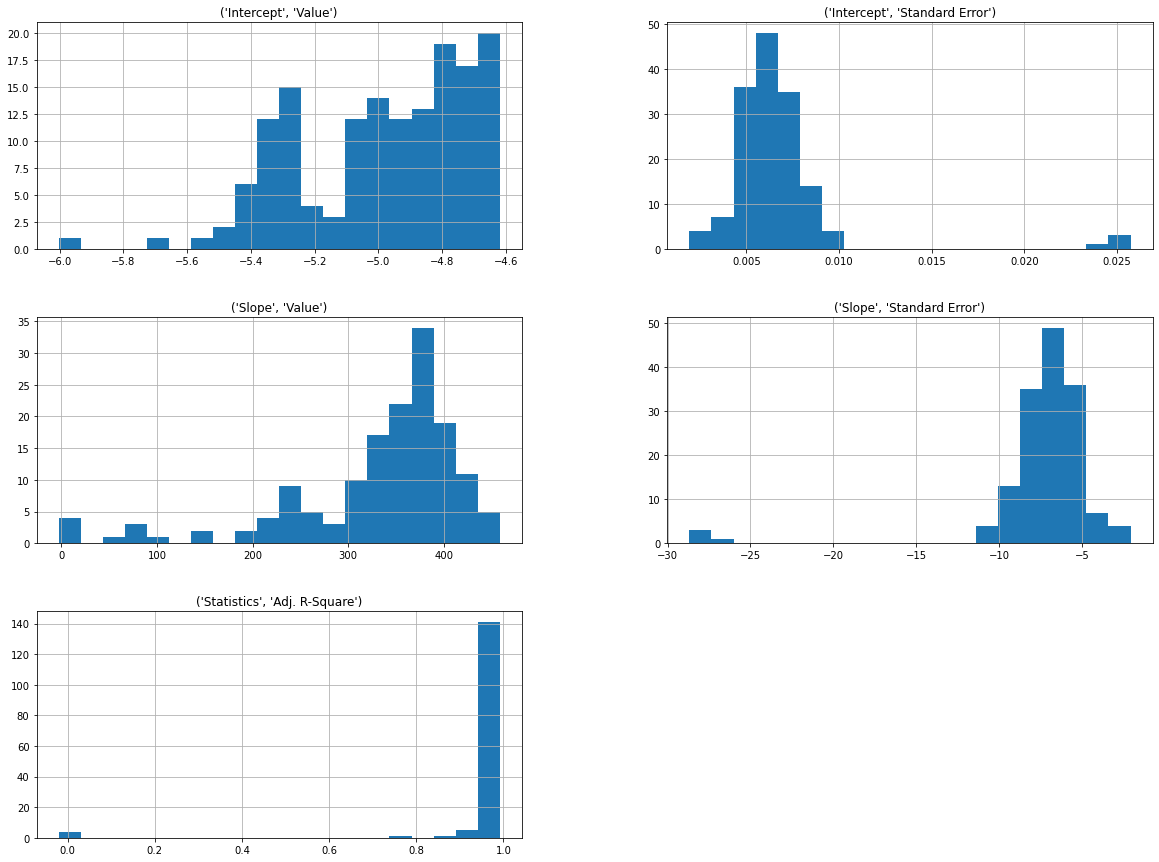

In [15]:
# all the devices at all the bias voltages
df_fom.hist(bins=, figsize=(20,15))
pp.show()

In [58]:
from scipy.stats import binom

n, p = 8, 0.5
mean, var, skew, kurt = binom.stats(¬n, p, moments='mskv')
print(f" mean = {mean},\n var = {var},\n skew = {skew},\n kurt={kurt}")

 mean = 4.0,
 var = 2.0,
 skew = 0.0,
 kurt=-0.25


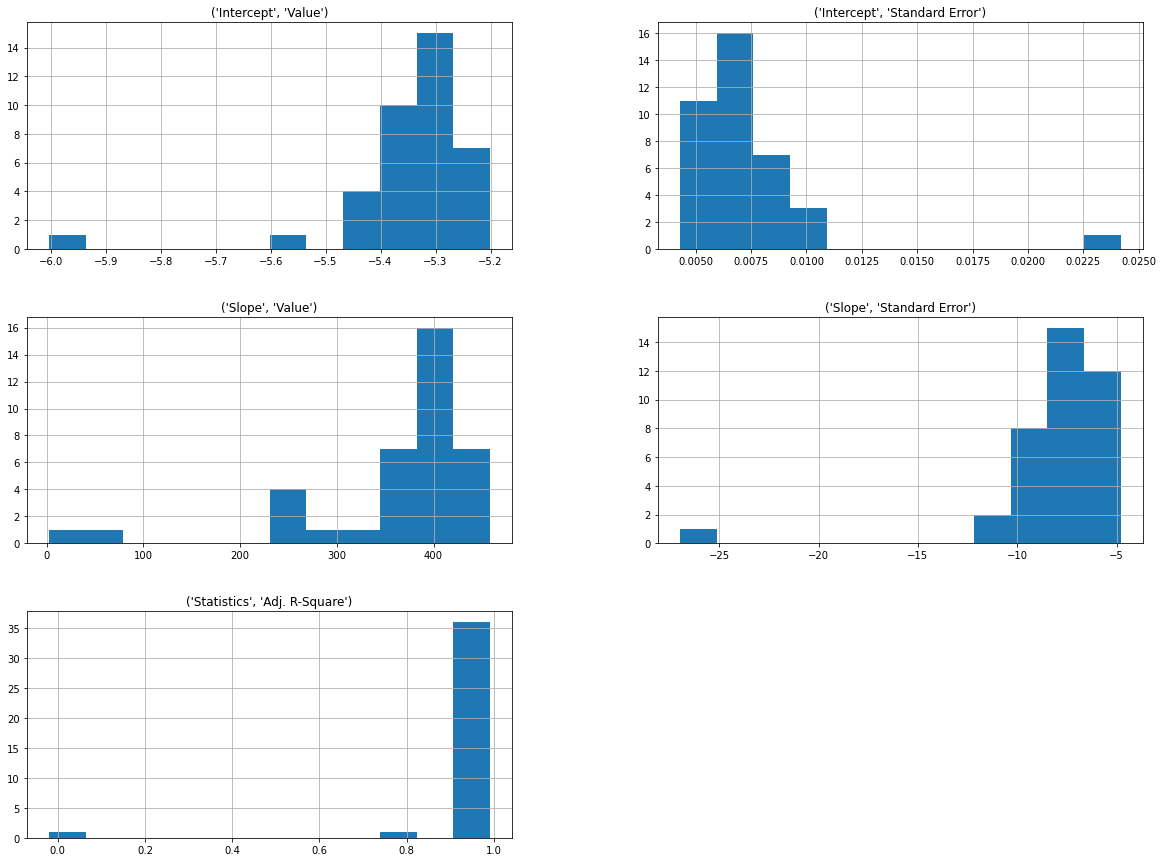

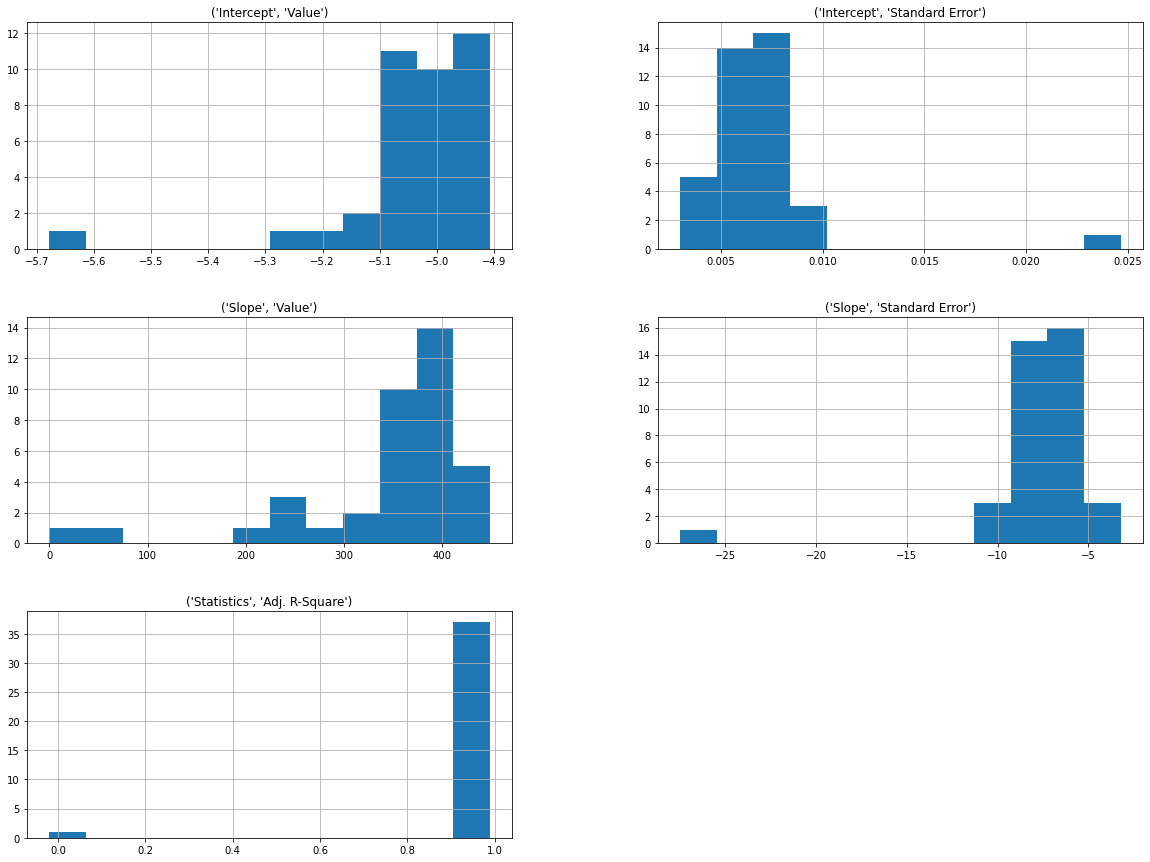

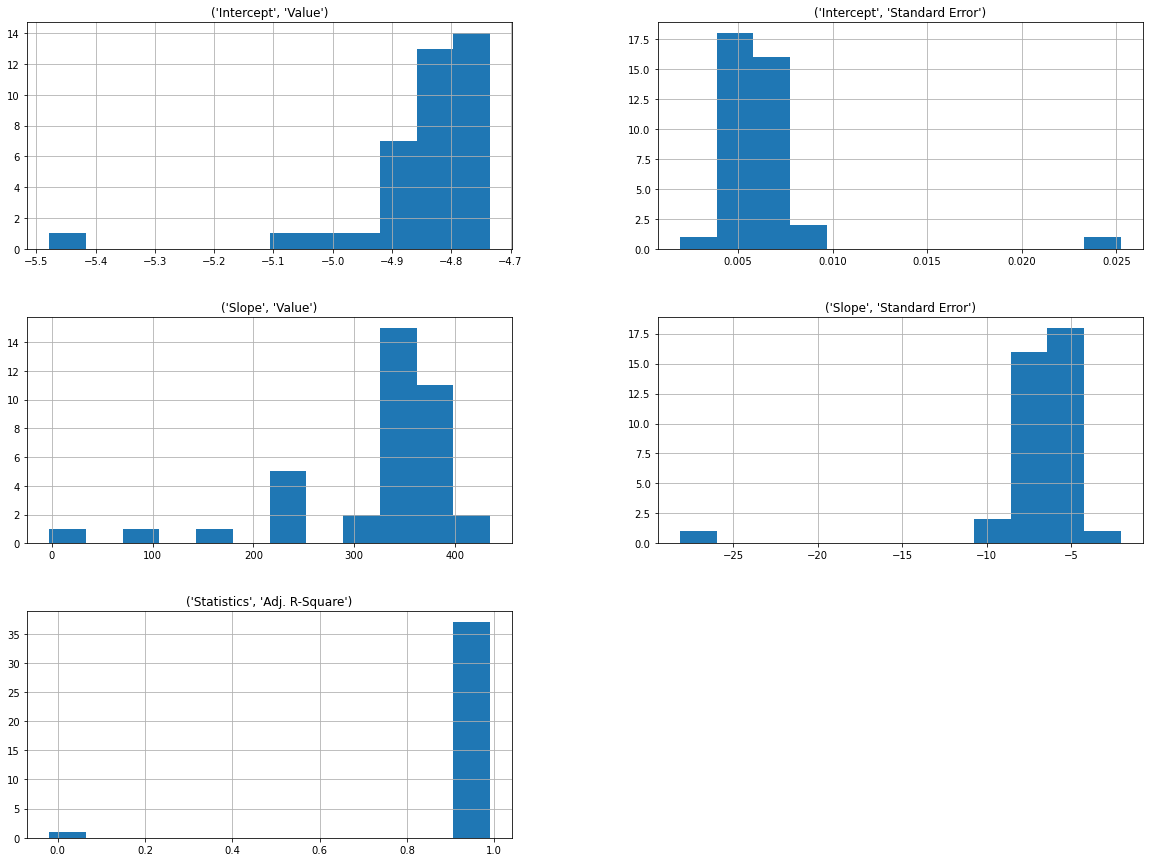

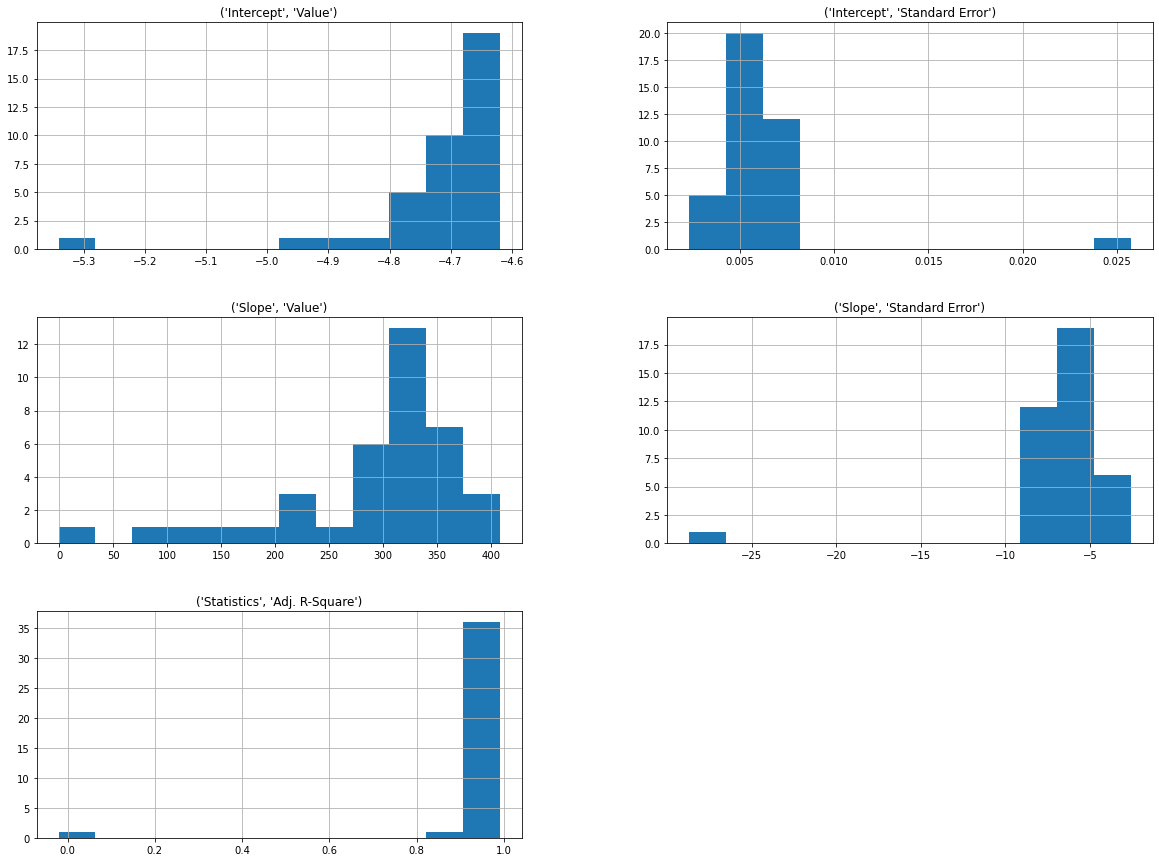

In [31]:
vsd = [0.1, 0.2, 0.3, 0.4]

for i in range(len(vsd)):
    df_fom.iloc[i::4,:].hist(bins=12, figsize=(20,15))
    pp.savefig(f'SS_Fit_Histresult_GT_{vsd[i] * 1e3}mV.png')



In [79]:
slope = np.array([-0.30607 ,-0.52175 ,-0.51711 ,-0.45377 ,-0.47125 ,-0.35352 ,-0.42711 ,-0.47318 ,-0.39696 ,-0.4395 ,-0.45126 ,-0.49732 ,-0.47806 ,-0.45278 ,-0.40142 ,-0.44564 ,-0.41988 ,-0.48376
,-0.45291 ,-0.29475 ,-0.4117 ,-0.51662 ,-0.45152 ,-0.41858 ,-0.4902 ,-0.4413 ,-0.45296 ,-0.21459 ,-0.43368 ,-0.28086 ,-0.2455 ,-0.42196 ,-0.41667 ,-0.42149 ,-0.32103 ,-0.48186])
1 / slope 

array([-3.26722645, -1.91662674, -1.93382452, -2.20375961, -2.12201592,
       -2.82869427, -2.34131723, -2.11336067, -2.51914551, -2.27531286,
       -2.21601737, -2.01077777, -2.09178764, -2.20857812, -2.49115639,
       -2.24396374, -2.38163285, -2.06714073, -2.20794418, -3.39270568,
       -2.42895312, -1.9356587 , -2.21474132, -2.38902958, -2.03998368,
       -2.26603218, -2.20770046, -4.6600494 , -2.30584763, -3.56049277,
       -4.07331976, -2.36989288, -2.3999808 , -2.37253553, -3.11497368,
       -2.07529158])

In [60]:
import scipy.constants as sc

sc.hbar
sc.elementary_charge
#sc.reduced_Planck_constant_in_eV_s
sc.physical_constants['reduced Planck constant in eV s'][0]

6.582119569e-16

In [66]:
vf  = 1e6 # ferm velocity of graphene [m/s]
Cg  = 1e-3 # Capacitive Coupling [690 aF/um^2 so I converted it]
DVg = 4.0 # [V]

delta_m = sc.physical_constants['reduced Planck constant in eV s'][0] * vf * (2 * np.pi * (Cg) * DVg / sc.elementary_charge) ** 1/2
delta_m_meV = delta_m * 1e-3
print(f'delta_m = {delta_m}, delta_m_meV = {delta_m_meV}')

delta_m = 51625614.91461626, delta_m_meV = 51625.61491461626


In [77]:
from datetime import date, timedelta

d0 = date(2021, 4, 18)
d1 = date(2022, 3, 15)
delta = d1 - d0
print(delta.days / 7)

47.285714285714285


In [216]:
# Python's program to print all Monday's of a specific year
 
def allsundays(year):
   d = date(year, 1, 1)                    # January 1st
   d += timedelta(days = 6 - d.weekday())  # First Sunday
   while d.year == year:
      yield d
      d += timedelta(days = 7)

submission_date = date(2022, 3, 15)
for d in allsundays(2022):
    if d > date.today() and d < submission_date:
         print(f'******* {d} Begin ******')
         print(f'Weeks left to Submission = {np.round((submission_date - d).days / 7, decimals=0)}')
         print(29*'*'+'\n')
         print(f'******** {d} End *******\n')

******* 2022-01-02 Begin ******
Weeks left to Submission = 10.0
*****************************

******** 2022-01-02 End *******

******* 2022-01-09 Begin ******
Weeks left to Submission = 9.0
*****************************

******** 2022-01-09 End *******

******* 2022-01-16 Begin ******
Weeks left to Submission = 8.0
*****************************

******** 2022-01-16 End *******

******* 2022-01-23 Begin ******
Weeks left to Submission = 7.0
*****************************

******** 2022-01-23 End *******

******* 2022-01-30 Begin ******
Weeks left to Submission = 6.0
*****************************

******** 2022-01-30 End *******

******* 2022-02-06 Begin ******
Weeks left to Submission = 5.0
*****************************

******** 2022-02-06 End *******

******* 2022-02-13 Begin ******
Weeks left to Submission = 4.0
*****************************

******** 2022-02-13 End *******

******* 2022-02-20 Begin ******
Weeks left to Submission = 3.0
*****************************

******** 2022-02

# Plot Histogram Manually

In [153]:
slope_array = np.array([-0.15183,-0.38573 ,-0.46631 ,-0.37996 ,-0.39492 ,-0.31019 ,-0.3363 ,-0.38424 ,-0.32068 ,-0.4267 ,-0.38373 ,-0.4476 ,-0.42954 ,-0.41025 ,-0.36731 ,-0.39161 ,-0.36125 ,-0.41727 ,-0.42316 ,-0.26872 ,-0.37147 ,-0.41755 ,-0.38609 ,-0.34826 ,-0.39332 ,-0.39461 ,-0.36141 ,-0.10558 ,-0.36967 ,-0.25977 ,-0.25353 ,-0.38647 ,-0.35165 ,-0.3091 ,-0.22341 ,-0.39486])

inverse_array = np.power(-slope_array, -1)
inverse_array
max = np.max(inverse_array)
min = np.min(inverse_array)
print(f'Max inverse array = {max}\nMin inverse array = {min}')




Max inverse array = 9.471490812653911
Min inverse array = 2.1444961506294096


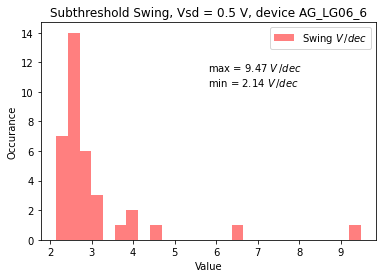

In [162]:
vsd             = 0.5 # [V]. Bias at which the trace is take
device_name     = 'AG_LG06_6'

# bins = 'auto' uses the maximum of the Sturges and Freedman-Diaconis bin choice. You can read more about the options in the
pp.hist(inverse_array, bins='auto', histtype='stepfilled', color='r', alpha=0.5, label='Swing $V\,/dec$')
xlabel, ylabel = 5.8, 1.1 * max
pp.text(xlabel, ylabel, f'max = {np.around(max, decimals=2)} $V\,/dec$\nmin = {np.around(min, decimals=2)} $V\,/dec$')
pp.title(f"Subthreshold Swing, Vsd = {vsd} V, device {device_name}")
pp.xlabel("Value")
pp.ylabel("Occurance")
pp.legend()
pp.show()

0.06927084092439074

In [97]:
max

4.208045783538125